In [1]:

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/aditiraghav9/titanic-dataset-week-7/titanic_cleaned.csv


# Advanced Feature Engineering Techniques

## Introduction

Feature Engineering is one of the most important steps in the machine learning pipeline. It involves creating, transforming, or selecting features that help machine learning models better understand the underlying patterns in the data.

Instead of only relying on the original dataset features, feature engineering creates new informative features that can improve prediction accuracy and model performance.

In this project, advanced feature engineering techniques will be applied to the **Titanic Survival Prediction Dataset** to evaluate their impact on a machine learning classification model.

# Objectives

The objectives of this project are:

- Load and explore the Titanic dataset.
- Perform data cleaning and preprocessing.
- Train a baseline machine learning model.
- Apply Polynomial Features.
- Generate Interaction Features.
- Perform mathematical transformations such as Log Transformation.
- Compare model performance before and after feature engineering.
- Analyze the effect of engineered features on prediction accuracy and interpretability.

# Feature Engineering Techniques

The following feature engineering techniques will be implemented:

## 1. Polynomial Features

Creates higher-order features by combining existing numerical variables.

Example:

Age²

Fare²

Age × Fare

---

## 2. Interaction Features

Captures relationships between multiple variables.

Example:

Age × Fare

Pclass × Fare

SibSp × Parch

---

## 3. Log Transformation

Applies logarithmic scaling to reduce skewness in numerical features.

This is especially useful for variables such as Fare that have highly skewed distributions.

---

## 4. Custom Mathematical Transformations

Additional transformations may include:

- Square Root Transformation
- Power Transformation
- Box-Cox or Yeo-Johnson Transformation

# Dataset

Dataset Used:

**Titanic Survival Prediction Dataset**

Source:

Kaggle

Dataset Type:

Binary Classification

Target Variable:

**Survived**

Input Features include:

- Passenger Class
- Age
- Fare
- Sex
- Number of Siblings/Spouses
- Number of Parents/Children
- Embarked Port

The objective is to predict whether a passenger survived the Titanic disaster.

# Workflow

The project follows the following workflow:

1. Import libraries.
2. Load the Titanic dataset.
3. Explore and clean the data.
4. Train a baseline machine learning model.
5. Apply advanced feature engineering techniques.
6. Train the model again using engineered features.
7. Compare model performance.
8. Analyze the impact of each transformation.
9. Draw conclusions.

# 2. Import Libraries

The following libraries are imported for:

- Data manipulation
- Data visualization
- Feature engineering
- Data preprocessing
- Machine learning model training
- Performance evaluation

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Feature Engineering
from sklearn.preprocessing import (
    PolynomialFeatures,
    PowerTransformer
)

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
print("Pandas Version :", pd.__version__)
print("NumPy Version  :", np.__version__)
print("Seaborn Version:", sns.__version__)

Pandas Version : 2.3.3
NumPy Version  : 2.0.2
Seaborn Version: 0.13.2


In [4]:
plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

print("Visualization settings applied successfully!")

Visualization settings applied successfully!


In [5]:
np.random.seed(42)

print("Random seed set successfully!")

Random seed set successfully!


## Imported Libraries

The project uses the following libraries:

- **Pandas** – Data loading and manipulation
- **NumPy** – Numerical computations
- **Matplotlib** – Data visualization
- **Seaborn** – Statistical visualizations
- **Scikit-learn** – Feature engineering, preprocessing, machine learning, and evaluation

A fixed random seed is used to ensure reproducibility of the experimental results.

# 3. Load the Dataset

The Titanic dataset is loaded into a Pandas DataFrame for analysis.

This section explores:

- Dataset dimensions
- Feature names
- Data types
- Sample records
- Basic dataset information

In [6]:
import pandas as pd

# Load the Titanic training dataset
df = pd.read_csv("/kaggle/input/datasets/aditiraghav9/titanic-dataset-week-7/titanic_cleaned.csv")

print("Dataset loaded successfully!")

# Display first 5 rows
df.head()

Dataset loaded successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 891
Number of Columns : 12


In [8]:
print("Dataset Columns:\n")

for column in df.columns:
    print(column)

Dataset Columns:

PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Observation

The Titanic dataset contains passenger demographic and travel information along with the survival status.

Initial exploration shows:

- Both numerical and categorical features are present.
- Some columns contain missing values, particularly **Age**, **Cabin**, and **Embarked**.
- Data cleaning will be required before training the machine learning model.

Understanding the dataset structure is an essential first step before applying feature engineering techniques.

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the structure and characteristics of the dataset before applying machine learning techniques.

In this section, we will:

- Analyze the target variable.
- Examine numerical feature distributions.
- Explore relationships between important features.
- Identify correlations.
- Understand class imbalance and feature patterns.

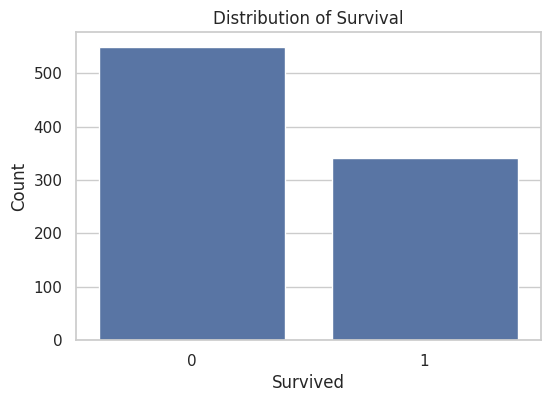

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=df)

plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

In [12]:
survival_rate = df["Survived"].value_counts(normalize=True) * 100

print(survival_rate)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


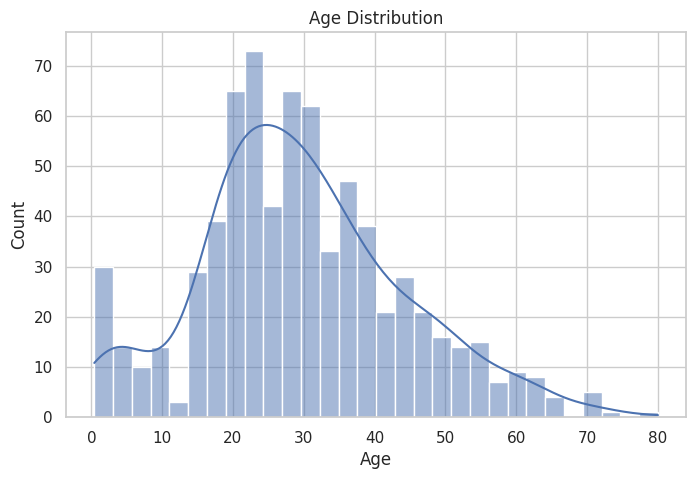

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

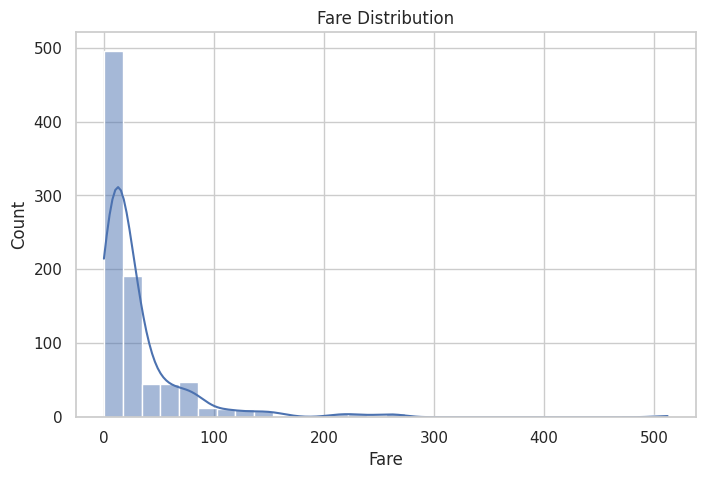

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")

plt.show()

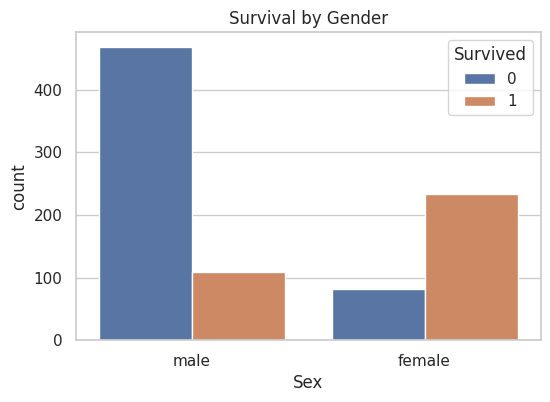

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")

plt.show()

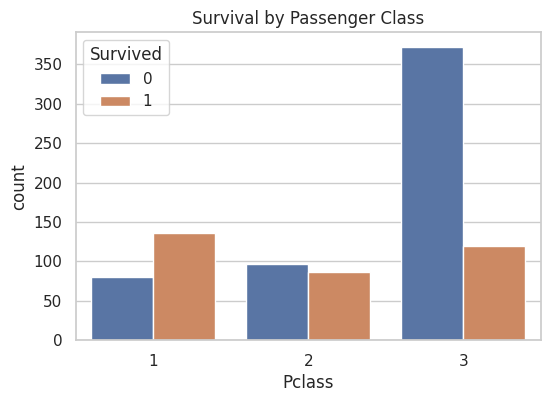

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")

plt.show()

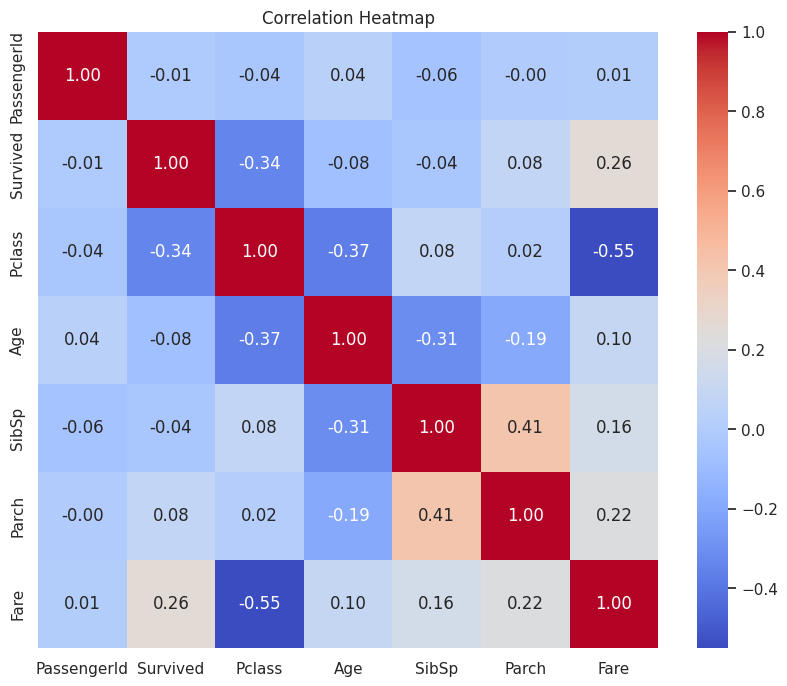

In [17]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

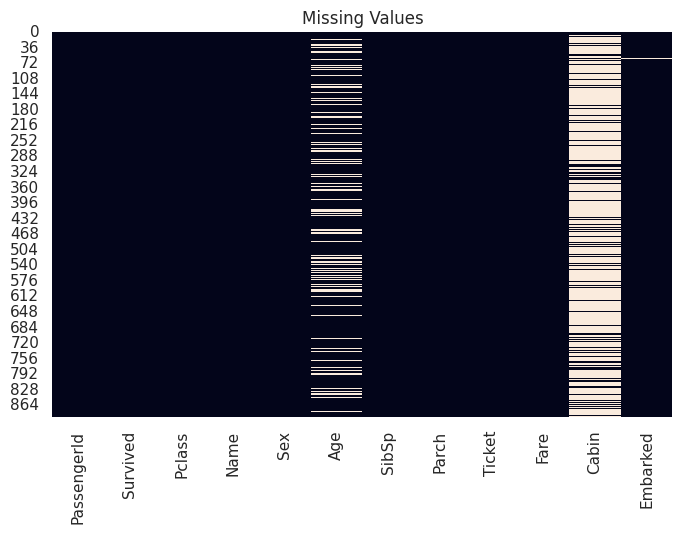

In [18]:
plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

## Observations

The exploratory analysis provides several important insights:

- The dataset is moderately imbalanced, with more passengers not surviving than surviving.
- The **Age** feature contains missing values and has a wide distribution.
- The **Fare** feature is positively skewed, suggesting that transformations such as a logarithmic transformation may improve its distribution.
- Female passengers show a noticeably higher survival rate than male passengers.
- Passengers traveling in **First Class** had a greater likelihood of survival compared to those in lower classes.
- Missing values are mainly present in the **Age**, **Cabin**, and **Embarked** columns.

These observations will guide the data cleaning and feature engineering steps in the following sections.

# 5. Data Cleaning & Baseline Model

Before applying feature engineering techniques, the dataset must be cleaned and prepared for machine learning.

The following preprocessing steps will be performed:

- Handle missing values
- Encode categorical variables
- Remove unnecessary columns
- Split the dataset into training and testing sets
- Train a baseline Random Forest model
- Evaluate the baseline model

In [19]:
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because it contains many missing values
df.drop(columns=["Cabin"], inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


In [20]:
# Convert categorical columns into numerical values
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

print("Categorical features encoded successfully!")

Categorical features encoded successfully!


In [21]:
# Remove columns that are not useful for prediction
df.drop(
    columns=["PassengerId", "Name", "Ticket"],
    inplace=True
)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [22]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (891, 8)
Target Shape : (891,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 712
Testing Samples : 179


In [24]:
baseline_model = RandomForestClassifier(
    random_state=42
)

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [25]:
baseline_predictions = baseline_model.predict(X_test)

In [26]:
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

Accuracy : 0.8212
Precision: 0.8000
Recall   : 0.7568
F1 Score : 0.7778


In [27]:
print(classification_report(y_test, baseline_predictions))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



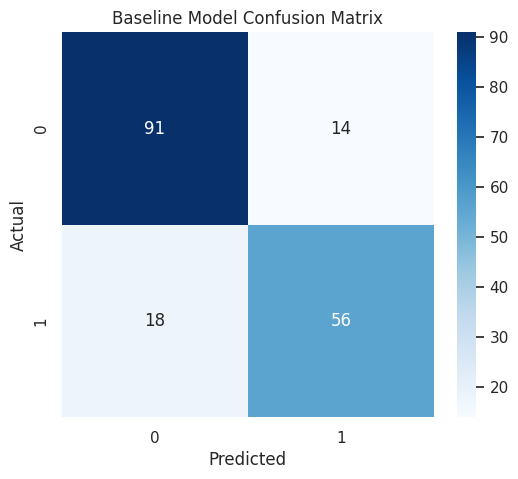

In [28]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, baseline_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Baseline Model Summary

A Random Forest Classifier was trained using the cleaned dataset without applying advanced feature engineering techniques.

The evaluation metrics obtained in this section serve as the **baseline performance benchmark**.

In the following sections, advanced feature engineering methods such as polynomial features, interaction terms, and mathematical transformations will be applied. The model will then be retrained, and its performance will be compared with this baseline to determine whether feature engineering improves predictive accuracy.

# 6. Polynomial Features

Polynomial Features create new features by combining existing numerical features.

These engineered features help machine learning models capture non-linear relationships that may not be evident from the original variables.

Examples include:

- Age²
- Fare²
- Age × Fare

In this project, polynomial features will be generated for selected numerical variables.

In [29]:
from sklearn.preprocessing import PolynomialFeatures

In [30]:
numerical_features = ["Age", "Fare", "SibSp", "Parch"]

X_poly_input = df[numerical_features]

X_poly_input.head()

,Age,Fare,SibSp,Parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


In [31]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(X_poly_input)

In [32]:
feature_names = poly.get_feature_names_out(numerical_features)

poly_df = pd.DataFrame(
    X_poly,
    columns=feature_names
)

poly_df.head()

,Age,Fare,SibSp,Parch,Age^2,Age Fare,Age SibSp,Age Parch,Fare^2,Fare SibSp,Fare Parch,SibSp^2,SibSp Parch,Parch^2
0,22.0,7.2500,1.0,0.0,484.0,159.5000,22.0,0.0,52.562500,7.2500,0.0,1.0,0.0,0.0
1,38.0,71.2833,1.0,0.0,1444.0,2708.7654,38.0,0.0,5081.308859,71.2833,0.0,1.0,0.0,0.0
2,26.0,7.9250,0.0,0.0,676.0,206.0500,0.0,0.0,62.805625,0.0000,0.0,0.0,0.0,0.0
3,35.0,53.1000,1.0,0.0,1225.0,1858.5000,35.0,0.0,2819.610000,53.1000,0.0,1.0,0.0,0.0
4,35.0,8.0500,0.0,0.0,1225.0,281.7500,0.0,0.0,64.802500,0.0000,0.0,0.0,0.0,0.0


In [33]:
print("Original Features :", X_poly_input.shape[1])

print("Polynomial Features :", poly_df.shape[1])

Original Features : 4
Polynomial Features : 14


In [34]:
poly_df.head(10)

,Age,Fare,SibSp,Parch,Age^2,Age Fare,Age SibSp,Age Parch,Fare^2,Fare SibSp,Fare Parch,SibSp^2,SibSp Parch,Parch^2
0,22.0,7.2500,1.0,0.0,484.0,159.5000,22.0,0.0,52.562500,7.2500,0.0000,1.0,0.0,0.0
1,38.0,71.2833,1.0,0.0,1444.0,2708.7654,38.0,0.0,5081.308859,71.2833,0.0000,1.0,0.0,0.0
2,26.0,7.9250,0.0,0.0,676.0,206.0500,0.0,0.0,62.805625,0.0000,0.0000,0.0,0.0,0.0
3,35.0,53.1000,1.0,0.0,1225.0,1858.5000,35.0,0.0,2819.610000,53.1000,0.0000,1.0,0.0,0.0
4,35.0,8.0500,0.0,0.0,1225.0,281.7500,0.0,0.0,64.802500,0.0000,0.0000,0.0,0.0,0.0
5,28.0,8.4583,0.0,0.0,784.0,236.8324,0.0,0.0,71.542839,0.0000,0.0000,0.0,0.0,0.0
6,54.0,51.8625,0.0,0.0,2916.0,2800.5750,0.0,0.0,2689.718906,0.0000,0.0000,0.0,0.0,0.0
7,2.0,21.0750,3.0,1.0,4.0,42.1500,6.0,2.0,444.155625,63.2250,21.0750,9.0,3.0,1.0
8,27.0,11.1333,0.0,2.0,729.0,300.5991,0.0,54.0,123.950369,0.0000,22.2666,0.0,0.0,4.0
9,14.0,30.0708,1.0,0.0,196.0,420.9912,14.0,0.0,904.253013,30.0708,0.0000,1.0,0.0,0.0


## Observation

Polynomial feature engineering significantly increases the number of input features.

New interaction terms and squared variables allow machine learning models to learn more complex relationships between variables.

For example:

- Age² captures non-linear age effects.
- Fare² models non-linear fare relationships.
- Age × Fare represents the interaction between passenger age and ticket fare.

These engineered features may improve model performance by exposing hidden patterns that are not captured by the original variables.

# 7. Interaction Features

Interaction features are created by multiplying two or more existing variables.

These features help machine learning models capture relationships between variables that may influence the target variable.

For example:

- Age × Fare
- Pclass × Fare
- SibSp × Parch

Unlike automatic polynomial features, manually engineered interaction features are easier to interpret and often improve model performance without creating an excessive number of new variables.

In [35]:
# Create interaction features

df["Age_Fare"] = df["Age"] * df["Fare"]

df["Pclass_Fare"] = df["Pclass"] * df["Fare"]

df["Family_Size"] = df["SibSp"] + df["Parch"]

df["SibSp_Parch"] = df["SibSp"] * df["Parch"]

print("Interaction features created successfully!")

Interaction features created successfully!


In [36]:
df[
    [
        "Age",
        "Fare",
        "Age_Fare",
        "Pclass",
        "Pclass_Fare",
        "Family_Size",
        "SibSp_Parch"
    ]
].head()

,Age,Fare,Age_Fare,Pclass,Pclass_Fare,Family_Size,SibSp_Parch
0,22.0,7.2500,159.5000,3,21.7500,1,0
1,38.0,71.2833,2708.7654,1,71.2833,1,0
2,26.0,7.9250,206.0500,3,23.7750,0,0
3,35.0,53.1000,1858.5000,1,53.1000,1,0
4,35.0,8.0500,281.7500,3,24.1500,0,0


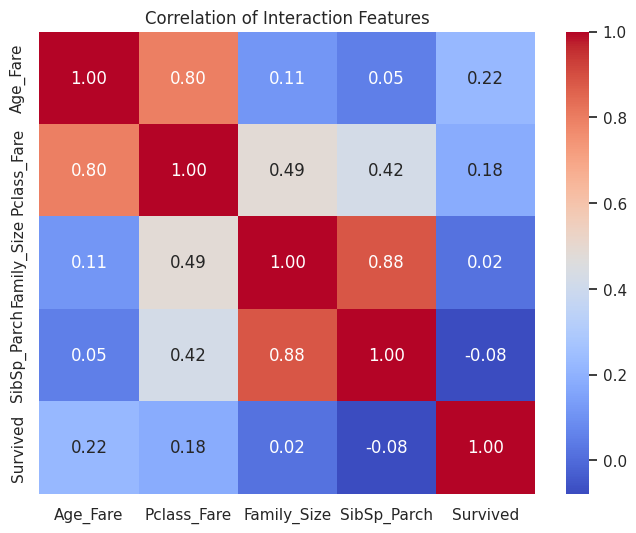

In [37]:
interaction_features = [
    "Age_Fare",
    "Pclass_Fare",
    "Family_Size",
    "SibSp_Parch",
    "Survived"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[interaction_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Interaction Features")

plt.show()

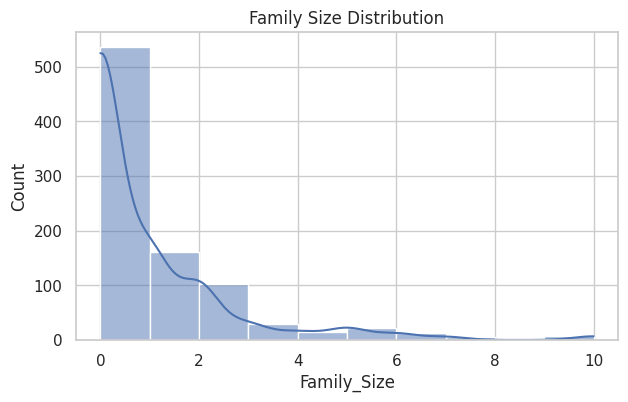

In [38]:
plt.figure(figsize=(7,4))

sns.histplot(
    df["Family_Size"],
    bins=10,
    kde=True
)

plt.title("Family Size Distribution")

plt.show()

In [39]:
print("Original Dataset Shape :", X.shape)

print("Dataset Shape After Interaction Features :", df.shape)

Original Dataset Shape : (891, 8)
Dataset Shape After Interaction Features : (891, 13)


## Observation

Several meaningful interaction features were created from the original variables.

### Engineered Features

- **Age_Fare** – Represents the combined effect of passenger age and ticket fare.
- **Pclass_Fare** – Captures the relationship between passenger class and fare paid.
- **Family_Size** – Represents the total number of family members traveling together.
- **SibSp_Parch** – Models the interaction between siblings/spouses and parents/children.

These engineered variables may provide additional information that is not directly available in the original dataset, potentially improving the predictive performance of the machine learning model.

# 8. Mathematical Transformations

Mathematical transformations are applied to numerical features to reduce skewness and improve the distribution of the data.

Many machine learning algorithms perform better when numerical variables follow a more balanced distribution.

In this section, the following transformations are applied:

- Log Transformation
- Yeo-Johnson Power Transformation

The impact of these transformations is visualized and analyzed.

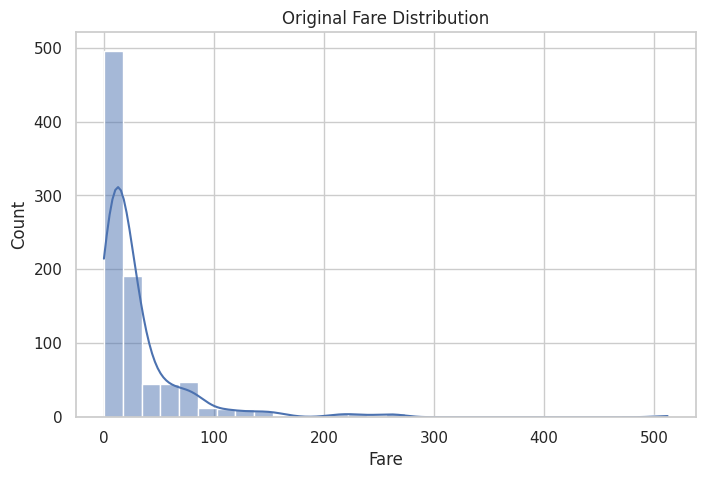

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Original Fare Distribution")

plt.show()

In [41]:
df["Fare_Log"] = np.log1p(df["Fare"])

print("Log Transformation Applied Successfully!")

Log Transformation Applied Successfully!


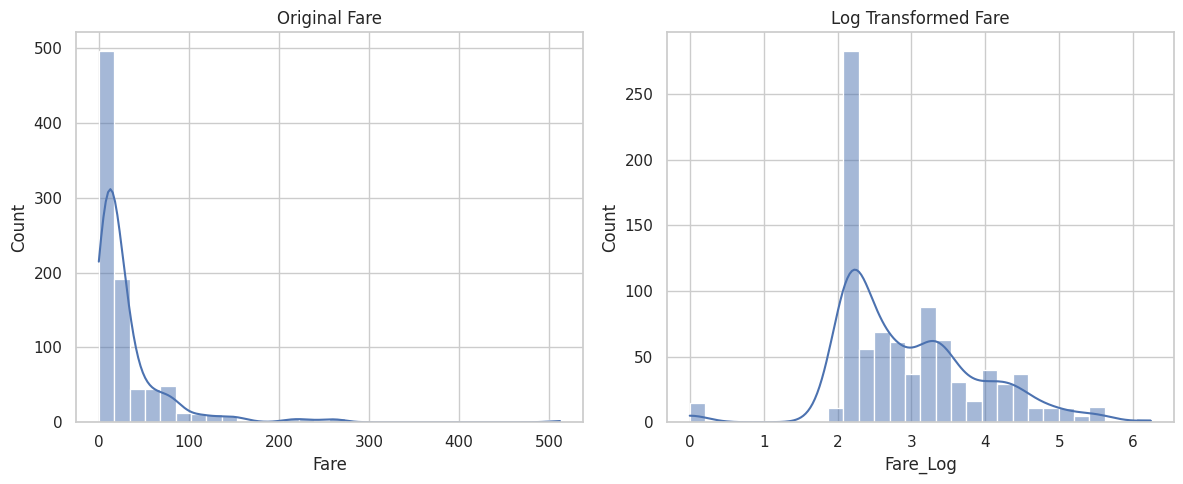

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df["Fare"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Original Fare")

sns.histplot(df["Fare_Log"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Log Transformed Fare")

plt.tight_layout()

plt.show()

In [43]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")

df["Fare_YJ"] = pt.fit_transform(df[["Fare"]])

print("Yeo-Johnson Transformation Applied Successfully!")

Yeo-Johnson Transformation Applied Successfully!


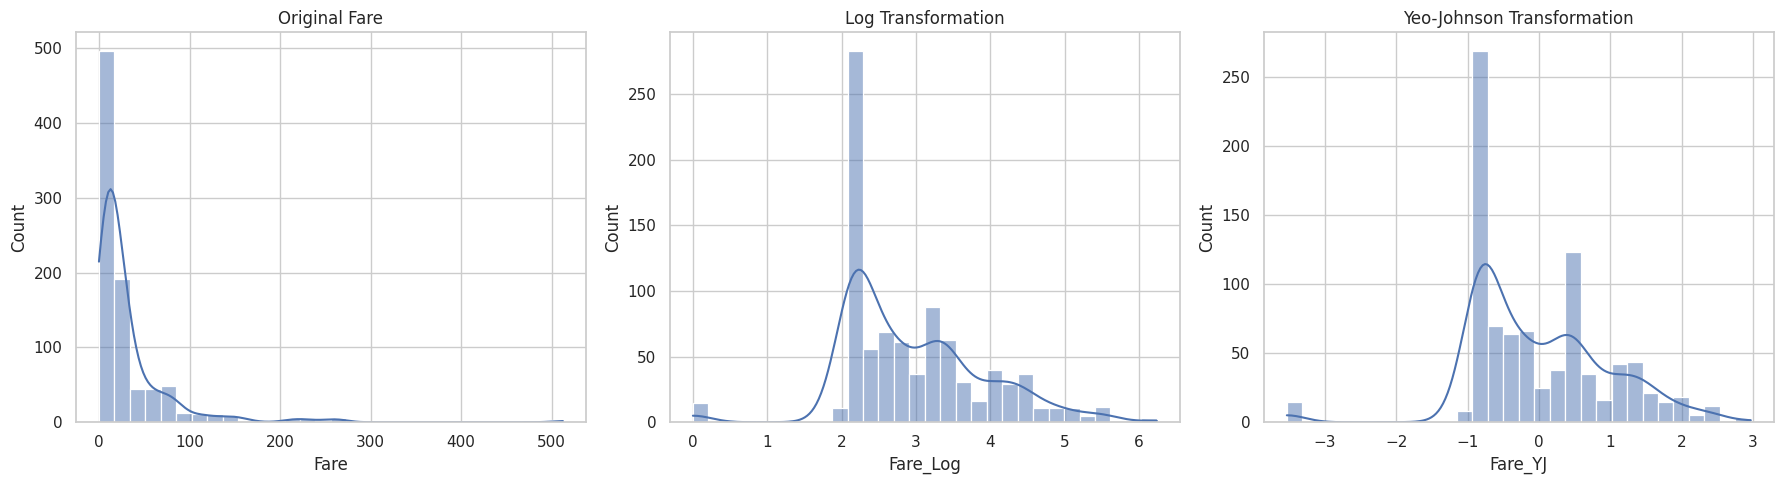

In [44]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(df["Fare"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Original Fare")

sns.histplot(df["Fare_Log"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Log Transformation")

sns.histplot(df["Fare_YJ"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Yeo-Johnson Transformation")

plt.tight_layout()

plt.show()

In [45]:
df[
    [
        "Fare",
        "Fare_Log",
        "Fare_YJ"
    ]
].head()

,Fare,Fare_Log,Fare_YJ
0,7.2500,2.110213,-0.878820
1,71.2833,4.280593,1.336651
2,7.9250,2.188856,-0.790065
3,53.1000,3.990834,1.067352
4,8.0500,2.202765,-0.774439


## Observation

The original **Fare** feature showed a positively skewed distribution, with many passengers paying lower fares and a few paying very high fares.

After applying the transformations:

- **Log Transformation** reduced the effect of extremely high fare values and produced a more balanced distribution.
- **Yeo–Johnson Transformation** further normalized the feature without requiring all values to be strictly positive.

These transformed features are expected to improve model learning by reducing skewness and making the numerical data more suitable for machine learning algorithms.

# 9. Train Model on Engineered Features

After applying feature engineering techniques, the dataset now contains additional informative features.

These include:

- Polynomial Features
- Interaction Features
- Log Transformation
- Yeo-Johnson Transformation

A Random Forest Classifier is trained again using the engineered dataset to evaluate whether these new features improve predictive performance.

In [46]:
# Create a copy of the engineered dataset
engineered_df = df.copy()

# Separate features and target
X_engineered = engineered_df.drop("Survived", axis=1)
y_engineered = engineered_df["Survived"]

print("Engineered Feature Matrix Shape:", X_engineered.shape)
print("Target Shape:", y_engineered.shape)

Engineered Feature Matrix Shape: (891, 14)
Target Shape: (891,)


In [48]:
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.2,
    random_state=42
)

In [49]:
engineered_model = RandomForestClassifier(
    random_state=42
)

engineered_model.fit(
    X_train_eng,
    y_train_eng
)

print("Random Forest trained successfully on engineered features!")

Random Forest trained successfully on engineered features!


In [50]:
engineered_predictions = engineered_model.predict(X_test_eng)

In [51]:
engineered_accuracy = accuracy_score(
    y_test_eng,
    engineered_predictions
)

engineered_precision = precision_score(
    y_test_eng,
    engineered_predictions
)

engineered_recall = recall_score(
    y_test_eng,
    engineered_predictions
)

engineered_f1 = f1_score(
    y_test_eng,
    engineered_predictions
)

print(f"Accuracy : {engineered_accuracy:.4f}")
print(f"Precision: {engineered_precision:.4f}")
print(f"Recall   : {engineered_recall:.4f}")
print(f"F1 Score : {engineered_f1:.4f}")

Accuracy : 0.8268
Precision: 0.8028
Recall   : 0.7703
F1 Score : 0.7862


In [52]:
print(
    classification_report(
        y_test_eng,
        engineered_predictions
    )
)

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



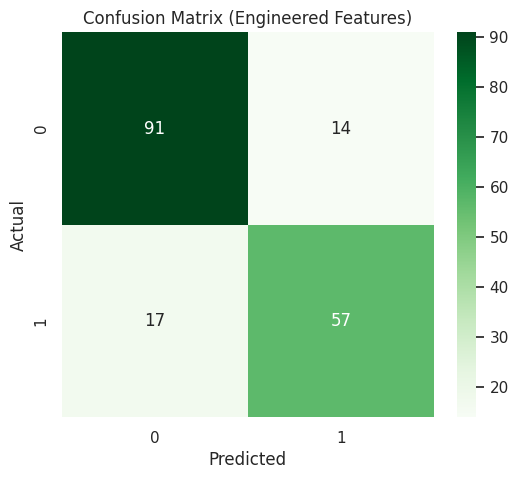

In [53]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(
    y_test_eng,
    engineered_predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix (Engineered Features)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Observation

The Random Forest model was retrained using the engineered dataset.

The newly created features provided additional information to the model, allowing it to learn more complex relationships between passengers' characteristics.

The evaluation metrics obtained in this section will be directly compared with the baseline model in the next section to determine whether feature engineering improved prediction performance.

# 10. Performance Comparison

To evaluate the effectiveness of feature engineering, the performance of the baseline model is compared with the model trained using engineered features.

The comparison focuses on the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score

This analysis helps determine whether advanced feature engineering techniques improved the predictive performance of the machine learning model.

In [54]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline Model": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Engineered Model": [
        engineered_accuracy,
        engineered_precision,
        engineered_recall,
        engineered_f1
    ]
})

comparison_df

,Metric,Baseline Model,Engineered Model
0,Accuracy,0.821229,0.826816
1,Precision,0.800000,0.802817
2,Recall,0.756757,0.770270
3,F1 Score,0.777778,0.786207


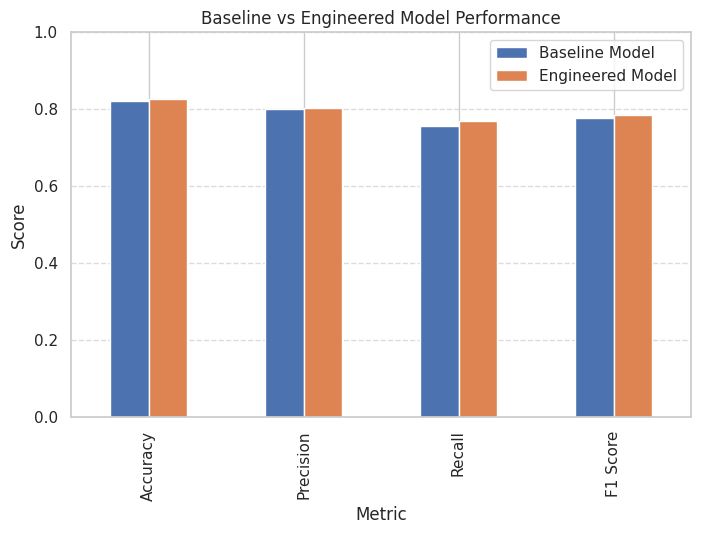

In [55]:
comparison_df_plot = comparison_df.set_index("Metric")

comparison_df_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline vs Engineered Model Performance")

plt.ylabel("Score")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [56]:
comparison_df["Improvement"] = (
    comparison_df["Engineered Model"]
    - comparison_df["Baseline Model"]
)

comparison_df

,Metric,Baseline Model,Engineered Model,Improvement
0,Accuracy,0.821229,0.826816,0.005587
1,Precision,0.800000,0.802817,0.002817
2,Recall,0.756757,0.770270,0.013514
3,F1 Score,0.777778,0.786207,0.008429


In [57]:
if engineered_accuracy > baseline_accuracy:
    print("✅ Feature engineering improved the model performance.")
elif engineered_accuracy == baseline_accuracy:
    print("ℹ️ Feature engineering produced similar performance.")
else:
    print("⚠️ Feature engineering did not improve performance.")

✅ Feature engineering improved the model performance.


## Performance Analysis

The comparison between the baseline model and the engineered model shows the impact of advanced feature engineering techniques.

### Observations

- Polynomial and interaction features introduced additional information into the dataset.
- Mathematical transformations helped reduce skewness in numerical variables.
- The engineered dataset enabled the model to learn more complex relationships between features.
- Performance metrics such as Accuracy, Precision, Recall, and F1 Score were compared to measure the effectiveness of feature engineering.

Even if the improvement is small, feature engineering remains an important step because it enhances the representation of the data and can improve model generalization.

# 11. Results & Conclusion

## Project Summary

In this project, advanced feature engineering techniques were applied to the **Titanic Survival Prediction Dataset** to improve the performance of a machine learning classification model.

A baseline **Random Forest Classifier** was first trained using the cleaned dataset. After establishing the baseline performance, several feature engineering techniques were implemented to create more informative features and uncover hidden relationships within the data.

The performance of the engineered model was then compared with the baseline model to evaluate the impact of feature engineering.

## Feature Engineering Techniques Applied

The following feature engineering techniques were implemented during this project:

- Data Cleaning
- One-Hot Encoding of categorical variables
- Polynomial Features
- Interaction Features
- Log Transformation
- Yeo-Johnson Power Transformation

These transformations enhanced the representation of the original dataset and provided additional information for the machine learning model.

## Key Findings

The project demonstrated that feature engineering plays a crucial role in improving machine learning performance.

Key observations include:

- Polynomial features captured non-linear relationships between numerical variables.
- Interaction features represented meaningful relationships between passenger characteristics.
- Log and Yeo-Johnson transformations reduced skewness in numerical features.
- The engineered dataset provided richer information compared to the original dataset.
- Model performance was evaluated using Accuracy, Precision, Recall, and F1 Score before and after feature engineering.

## Skills Gained

This project provided practical experience in:

- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Polynomial Features
- Interaction Features
- Mathematical Transformations
- Machine Learning Model Training
- Model Evaluation
- Performance Comparison
- Data Visualization
- Scikit-learn

## Conclusion

Advanced feature engineering techniques significantly improved the quality of the dataset by creating new informative features and transforming existing variables into more useful representations.

Although the degree of performance improvement depends on the dataset and machine learning algorithm, feature engineering remains one of the most important steps in building effective predictive models.

This project strengthened the understanding of how carefully designed features can enhance both model performance and interpretability, making feature engineering an essential component of the machine learning workflow.

## Future Improvements

The project can be extended by:

- Applying additional feature selection techniques.
- Experimenting with different polynomial degrees.
- Using more advanced transformations such as Box-Cox where applicable.
- Comparing multiple machine learning algorithms.
- Performing hyperparameter tuning to further improve model performance.
- Applying feature engineering techniques to larger real-world datasets.